In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install statsmodels


Note: you may need to restart the kernel to use updated packages.


# Pearson and Spearman correlation

Loading and cleaning meteorological data...

Columns in CC_SOUID121039.csv:
['SOUID', '    DATE', '   CC', ' Q_CC']
Loaded CC: 24503 valid records out of 24595 total

Columns in FG_SOUID121048.csv:
['SOUID', '    DATE', '   FG', ' Q_FG']
Loaded FG: 24215 valid records out of 24289 total

Columns in FX_SOUID121049.csv:
['SOUID', '    DATE', '   FX', ' Q_FX']
Loaded FX: 24522 valid records out of 24595 total

Columns in HU_SOUID121047.csv:
['SOUID', '    DATE', '   HU', ' Q_HU']
Loaded HU: 24525 valid records out of 24595 total

Columns in PP_SOUID121041.csv:
['SOUID', '    DATE', '   PP', ' Q_PP']
Loaded PP: 22071 valid records out of 24533 total

Columns in QQ_SOUID210447.csv:
['SOUID', '    DATE', '   QQ', ' Q_QQ']
Loaded QQ: 22583 valid records out of 24837 total

Columns in RR_SOUID121042.csv:
['SOUID', '    DATE', '   RR', ' Q_RR']
Loaded RR: 34273 valid records out of 34273 total

Columns in SD_SOUID121043.csv:
['SOUID', '    DATE', '   SD', ' Q_SD']
Loaded SD: 23710 valid records

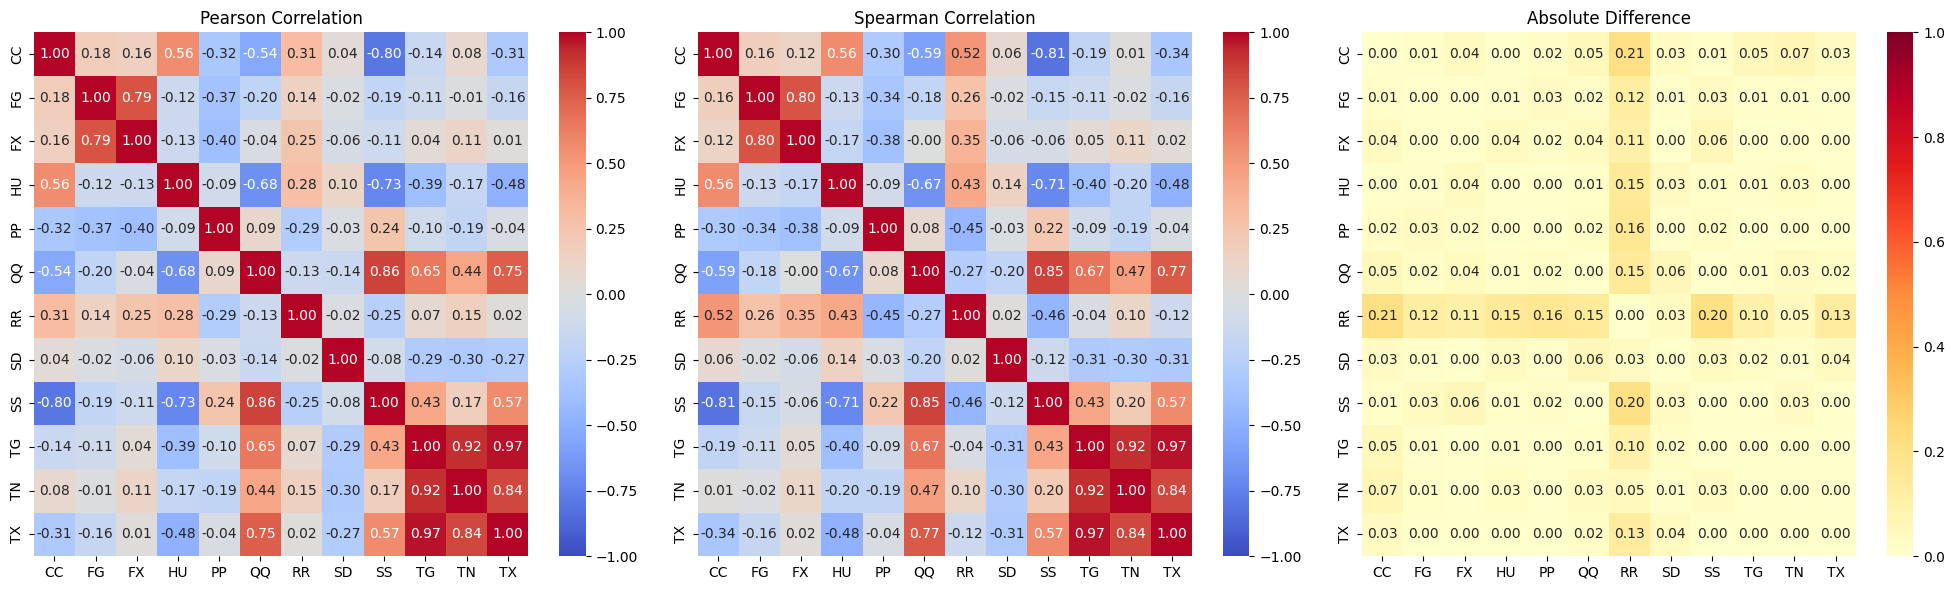

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def load_meteorological_data(files_dict):
    """
    Load meteorological data files with quality control
    
    Each CSV has 4 columns with headers:
    - Source identifier
    - DATE
    - Value
    - Quality code (0=valid, 1=suspect, 9=missing)
    """
    data = {}
    
    for var_name, (filename, description) in files_dict.items():
        try:
            # Read CSV with header, skip empty lines
            df = pd.read_csv(filename, skip_blank_lines=True)
            
            # Print column names to debug
            print(f"\nColumns in {filename}:")
            print(df.columns.tolist())
            
            if len(df.columns) == 4:
                # Strip whitespace from column names and values
                df.columns = [col.strip() for col in df.columns]
                for col in df.columns:
                    if df[col].dtype == object:
                        df[col] = df[col].str.strip()
                
                # Get the actual column names
                source_col = [col for col in df.columns if 'SOUID' in col.upper()][0]
                date_col = [col for col in df.columns if 'DATE' in col.upper()][0]
                value_col = [col for col in df.columns if var_name in col.upper()][0]
                quality_col = [col for col in df.columns if 'Q_' in col.upper()][0]
                
                # Convert date to datetime
                df[date_col] = pd.to_datetime(df[date_col], format='%Y%m%d')
                
                # Convert value column to numeric, handling negative values
                df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
                
                # Filter for valid measurements only (quality_code = 0)
                # First ensure quality code is numeric and stripped of whitespace
                df[quality_col] = pd.to_numeric(df[quality_col].astype(str).str.strip(), errors='coerce')
                df_clean = df[df[quality_col] == 0]
                
                # Remove any -9999 values which indicate missing data
                df_clean = df_clean[df_clean[value_col] != -9999]
                
                # Store the cleaned values series with datetime index
                data[var_name] = df_clean.set_index(date_col)[value_col]
                
                print(f"Loaded {var_name}: {len(df_clean)} valid records out of {len(df)} total")
            else:
                print(f"Warning: Unexpected number of columns in {filename}")
                
        except FileNotFoundError:
            print(f"Warning: Could not find file {filename}")
        except Exception as e:
            print(f"Error loading {filename}: {str(e)}")
            print("First few lines of the file:")
            try:
                with open(filename, 'r') as f:
                    for _ in range(5):
                        print(f.readline().strip())
            except:
                pass
    
    return data

def analyze_data_quality(data):
    """Analyze data quality after cleaning"""
    quality_report = {}
    
    for col in data.columns:
        series = data[col]
        quality_report[col] = {
            'missing_values': series.isnull().sum(),
            'unique_values': series.nunique(),
            'zeros': (series == 0).sum(),
            'range': series.max() - series.min(),
            'mean': series.mean(),
            'std': series.std(),
            'valid_records': len(series.dropna())
        }
    
    return pd.DataFrame(quality_report).T

def robust_analyze_correlations(data):
    """Analyze correlations with better handling of data issues"""
    # First check data quality
    print("\nData Quality Report:")
    print("-" * 50)
    quality_report = analyze_data_quality(data)
    print(quality_report)
    
    # Remove columns with zero variance
    std_dev = data.std()
    valid_columns = std_dev[std_dev > 0].index
    if len(valid_columns) < len(data.columns):
        print("\nWarning: Removing columns with zero variance:", 
              set(data.columns) - set(valid_columns))
        data = data[valid_columns]
    
    # Calculate correlations
    pearson_corr = data.corr(method='pearson')
    spearman_corr = data.corr(method='spearman')
    
    # Calculate absolute differences
    correlation_diff = abs(pearson_corr - spearman_corr)
    
    # Create visualizations
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Pearson correlation heatmap
    sns.heatmap(pearson_corr, 
                annot=True, 
                fmt='.2f',
                cmap='coolwarm', 
                vmin=-1, 
                vmax=1,
                ax=axes[0])
    axes[0].set_title('Pearson Correlation')
    
    # Spearman correlation heatmap
    sns.heatmap(spearman_corr, 
                annot=True, 
                fmt='.2f',
                cmap='coolwarm', 
                vmin=-1, 
                vmax=1,
                ax=axes[1])
    axes[1].set_title('Spearman Correlation')
    
    # Difference heatmap
    sns.heatmap(correlation_diff,
                annot=True,
                fmt='.2f',
                cmap='YlOrRd',
                vmin=0,
                vmax=1,
                ax=axes[2])
    axes[2].set_title('Absolute Difference')
    
    plt.tight_layout()
    
    # Print summary of major differences
    print("\nMajor Differences between Pearson and Spearman Correlations:")
    print("-" * 50)
    significant_diff = correlation_diff.unstack()
    significant_diff = significant_diff[significant_diff > 0.1]
    significant_diff = significant_diff[~significant_diff.isna()]
    
    if len(significant_diff) > 0:
        for (var1, var2), diff in significant_diff.items():
            if var1 != var2:  # Skip diagonal
                print(f"{var1} vs {var2}: {diff:.3f}")
                print(f"  Pearson: {pearson_corr.loc[var1, var2]:.3f}")
                print(f"  Spearman: {spearman_corr.loc[var1, var2]:.3f}")
    else:
        print("No major differences found (threshold > 0.1)")
    
    return pearson_corr, spearman_corr, correlation_diff

# Main execution
if __name__ == "__main__":
    # Your files_dict definition remains the same
    files_dict = {
        'CC': ('CC_SOUID121039.csv', 'cloud cover in oktas'),
        'FG': ('FG_SOUID121048.csv', 'wind speed in 0.1 m/s'),
        'FX': ('FX_SOUID121049.csv', 'wind gust in 0.1 m/s'),
        'HU': ('HU_SOUID121047.csv', 'humidity in 1 %'),
        'PP': ('PP_SOUID121041.csv', 'sea level pressure in 0.1 hPa'),
        'QQ': ('QQ_SOUID210447.csv', 'global radiation in W/m2'),
        'RR': ('RR_SOUID121042.csv', 'precipitation amount in 0.1 mm'),
        'SD': ('SD_SOUID121043.csv', 'snow depth in 1 cm'),
        'SS': ('SS_SOUID121040.csv', 'sunshine in 0.1 Hours'),
        'TG': ('TG_SOUID121044.csv', 'mean temperature in 0.1 °C'),
        'TN': ('TN_SOUID121045.csv', 'minimum temperature in 0.1 °C'),
        'TX': ('TX_SOUID121046.csv', 'maximum temperature in 0.1 °C')
    }
    
    # Load and clean the data
    print("Loading and cleaning meteorological data...")
    data = load_meteorological_data(files_dict)
    
    if not data:
        print("No data was loaded. Please check the file paths and try again.")
    else:
        # Convert to DataFrame
        df = pd.DataFrame(data)
        
        # Run the robust analysis
        pearson_corr, spearman_corr, correlation_diff = robust_analyze_correlations(df)
        
        # Show plots
        plt.show()

In [6]:
# # Import necessary libraries
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy import stats






# def visualize_relationships(data):
#     """
#     Visualize pairwise relationships in the dataset using scatterplots.
#     Categorize relationships as linear, monotonic, or weak.
#     """
#     pairs = [(col1, col2) for i, col1 in enumerate(data.columns) 
#                              for col2 in data.columns[i+1:]]
    
#     print("\nVisualizing relationships between variable pairs:")
#     for col1, col2 in pairs:
#         # Drop rows with missing values in either column
#         pair_data = data[[col1, col2]].dropna()
        
#         # Ensure there are enough data points to plot
#         if len(pair_data) < 2:
#             print(f"Skipping {col1} vs {col2}: Not enough valid data points.")
#             continue
        
#         print(f"Plotting {col1} vs {col2}...")
        
#         # Scatterplot
#         plt.figure(figsize=(6, 6))
#         sns.scatterplot(x=pair_data[col1], y=pair_data[col2], alpha=0.7)
#         plt.title(f'{col1} vs {col2}')
#         plt.xlabel(col1)
#         plt.ylabel(col2)
        
#         # Add Pearson and Spearman correlations to the plot
#         pearson_corr, _ = stats.pearsonr(pair_data[col1], pair_data[col2])
#         spearman_corr, _ = stats.spearmanr(pair_data[col1], pair_data[col2])
        
#         plt.text(0.05, 0.95, f'Pearson: {pearson_corr:.2f}\nSpearman: {spearman_corr:.2f}',
#                  transform=plt.gca().transAxes, 
#                  fontsize=12, 
#                  verticalalignment='top',
#                  bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='white'))
        
#         plt.show()
        
#         # Interpret Relationship Type
#         diff = abs(pearson_corr - spearman_corr)
#         if diff > 0.2:
#             print(f"  Significant difference detected ({diff:.2f}): Likely non-linear monotonic.")
#         elif abs(pearson_corr) > 0.3:
#             print(f"  Likely linear relationship (Pearson: {pearson_corr:.2f}).")
#         else:
#             print(f"  Weak or no clear relationship detected.")
#     print("Visualization complete.")



# # Main execution
# if __name__ == "__main__":
#     # Your files_dict definition remains the same
#     files_dict = {
#         'CC': ('CC_SOUID121039.csv', 'cloud cover in oktas'),
#         'FG': ('FG_SOUID121048.csv', 'wind speed in 0.1 m/s'),
#         'FX': ('FX_SOUID121049.csv', 'wind gust in 0.1 m/s'),
    #     'HU': ('HU_SOUID121047.csv', 'humidity in 1 %'),
    #     'PP': ('PP_SOUID121041.csv', 'sea level pressure in 0.1 hPa'),
    #     'QQ': ('QQ_SOUID210447.csv', 'global radiation in W/m2'),
    #     'RR': ('RR_SOUID121042.csv', 'precipitation amount in 0.1 mm'),
    #     'SD': ('SD_SOUID121043.csv', 'snow depth in 1 cm'),
    #     'SS': ('SS_SOUID121040.csv', 'sunshine in 0.1 Hours'),
    #     'TG': ('TG_SOUID121044.csv', 'mean temperature in 0.1 °C'),
    #     'TN': ('TN_SOUID121045.csv', 'minimum temperature in 0.1 °C'),
    #     'TX': ('TX_SOUID121046.csv', 'maximum temperature in 0.1 °C')
    # }
    
    
    # # Load and clean the data
    # print("Loading and cleaning meteorological data...")
    # data = load_meteorological_data(files_dict)
    
    # if not data:
    #     print("No data was loaded. Please check the file paths and try again.")
    # else:
    #     # Convert to DataFrame
    #     df = pd.DataFrame(data)
        
    #     # Run the robust analysis
    #     pearson_corr, spearman_corr, correlation_diff = robust_analyze_correlations(df)
        
    #     # Visualize relationships
    #     visualize_relationships(df)
        
    #     # Show plots
    #     plt.show()


In [7]:
# def get_linear_relationships(data, threshold=0.3):
#     """
#     Identify variable pairs with likely linear relationships.
    
#     Parameters:
#     - data: DataFrame containing the variables.
#     - threshold: Minimum absolute Pearson correlation value to consider a relationship as linear.
    
#     Returns:
#     - List of tuples (variable1, variable2, Pearson correlation, Spearman correlation)
#     """
#     pairs = [(col1, col2) for i, col1 in enumerate(data.columns) 
#                              for col2 in data.columns[i+1:]]
#     linear_relationships = []
    
#     for col1, col2 in pairs:
#         # Drop rows with missing values in either column
#         pair_data = data[[col1, col2]].dropna()
        
#         if len(pair_data) < 2:
#             continue  # Skip pairs with insufficient data
        
#         # Calculate correlations
#         pearson_corr, _ = stats.pearsonr(pair_data[col1], pair_data[col2])
#         spearman_corr, _ = stats.spearmanr(pair_data[col1], pair_data[col2])
        
#         # Check for linear relationship based on Pearson correlation
#         if abs(pearson_corr) >= threshold:
#             linear_relationships.append((col1, col2, pearson_corr, spearman_corr))
    
#     return linear_relationships

# Main execution
# if __name__ == "__main__":
#     # Your files_dict definition remains the same
#     files_dict = {
#         'CC': ('CC_SOUID121039.csv', 'cloud cover in oktas'),
#         'FG': ('FG_SOUID121048.csv', 'wind speed in 0.1 m/s'),
#         'FX': ('FX_SOUID121049.csv', 'wind gust in 0.1 m/s'),
#         'HU': ('HU_SOUID121047.csv', 'humidity in 1 %'),
#         'PP': ('PP_SOUID121041.csv', 'sea level pressure in 0.1 hPa'),
#         'QQ': ('QQ_SOUID210447.csv', 'global radiation in W/m2'),
#         'RR': ('RR_SOUID121042.csv', 'precipitation amount in 0.1 mm'),
#         'SD': ('SD_SOUID121043.csv', 'snow depth in 1 cm'),
#         'SS': ('SS_SOUID121040.csv', 'sunshine in 0.1 Hours'),
#         'TG': ('TG_SOUID121044.csv', 'mean temperature in 0.1 °C'),
#         'TN': ('TN_SOUID121045.csv', 'minimum temperature in 0.1 °C'),
#         'TX': ('TX_SOUID121046.csv', 'maximum temperature in 0.1 °C')
#     }
    
#     # Load and clean the data
#     print("Loading and cleaning meteorological data...")
#     data = load_meteorological_data(files_dict)
    
#     if not data:
#         print("No data was loaded. Please check the file paths and try again.")
#     else:
#         # Convert to DataFrame
#         df = pd.DataFrame(data)
        
#         # Identify linear relationships
#         linear_relationships = get_linear_relationships(df)
        
#         # Print results
#         print("\nVariable Pairs with Likely Linear Relationships:")
#         print("-" * 50)
#         for var1, var2, pearson_corr, spearman_corr in linear_relationships:
#             print(f"{var1} vs {var2}:")
#             print(f"  Pearson: {pearson_corr:.3f}")
#             print(f"  Spearman: {spearman_corr:.3f}")


In [8]:
from scipy import stats
import pandas as pd

def get_correlations_with_target(data, target_variable, lower_threshold=-0.2, upper_threshold=0.2):
    """
    Identify variables with Pearson correlation below or above specified thresholds with the target variable.
    
    Parameters:
    - data: DataFrame containing the variables.
    - target_variable: The variable to compare others against.
    - lower_threshold: Minimum Pearson correlation value (negative threshold).
    - upper_threshold: Maximum Pearson correlation value (positive threshold).
    
    Returns:
    - List of tuples (variable, Pearson correlation, Spearman correlation)
    """
    relationships = []
    
    for col in data.columns:
        if col == target_variable:
            continue  # Skip correlation with itself
        
        # Drop rows with missing values in either column
        pair_data = data[[target_variable, col]].dropna()
        
        if len(pair_data) < 2:
            continue  # Skip pairs with insufficient data
        
        # Calculate correlations
        pearson_corr, _ = stats.pearsonr(pair_data[target_variable], pair_data[col])
        spearman_corr, _ = stats.spearmanr(pair_data[target_variable], pair_data[col])
        
        # Check if the Pearson correlation meets the thresholds
        if pearson_corr <= lower_threshold or pearson_corr >= upper_threshold:
            relationships.append((col, pearson_corr, spearman_corr))
    
    return relationships

# Main execution

if __name__ == "__main__":
    # Your files_dict definition remains the same
    files_dict = {
        'CC': ('CC_SOUID121039.csv', 'cloud cover in oktas'),
        'FG': ('FG_SOUID121048.csv', 'wind speed in 0.1 m/s'),
        'FX': ('FX_SOUID121049.csv', 'wind gust in 0.1 m/s'),
        'HU': ('HU_SOUID121047.csv', 'humidity in 1 %'),
        'PP': ('PP_SOUID121041.csv', 'sea level pressure in 0.1 hPa'),
        'QQ': ('QQ_SOUID210447.csv', 'global radiation in W/m2'),
        'RR': ('RR_SOUID121042.csv', 'precipitation amount in 0.1 mm'),
        'SD': ('SD_SOUID121043.csv', 'snow depth in 1 cm'),
        'SS': ('SS_SOUID121040.csv', 'sunshine in 0.1 Hours'),
        'TG': ('TG_SOUID121044.csv', 'mean temperature in 0.1 °C'),
        'TN': ('TN_SOUID121045.csv', 'minimum temperature in 0.1 °C'),
        'TX': ('TX_SOUID121046.csv', 'maximum temperature in 0.1 °C')
    }
    
    # Load and clean the data
    print("Loading and cleaning meteorological data...")
    data = load_meteorological_data(files_dict)
    
    if not data:
        print("No data was loaded. Please check the file paths and try again.")
    else:
        # Convert to DataFrame
        df = pd.DataFrame(data)
        
        # Identify relationships with the target variable
        target_variable = 'TG'
        relationships = get_correlations_with_target(df, target_variable)
        
        # Print results
        print(f"\nVariables with Pearson correlation <= -0.2 or >= 0.2 with {target_variable}:")
        print("-" * 60)
        for var, pearson_corr, spearman_corr in relationships:
            print(f"{target_variable} vs {var}:")
            print(f"  Pearson Correlation: {pearson_corr:.3f}")
            print(f"  Spearman Correlation: {spearman_corr:.3f}")


Loading and cleaning meteorological data...

Columns in CC_SOUID121039.csv:
['SOUID', '    DATE', '   CC', ' Q_CC']
Loaded CC: 24503 valid records out of 24595 total

Columns in FG_SOUID121048.csv:
['SOUID', '    DATE', '   FG', ' Q_FG']
Loaded FG: 24215 valid records out of 24289 total

Columns in FX_SOUID121049.csv:
['SOUID', '    DATE', '   FX', ' Q_FX']
Loaded FX: 24522 valid records out of 24595 total

Columns in HU_SOUID121047.csv:
['SOUID', '    DATE', '   HU', ' Q_HU']
Loaded HU: 24525 valid records out of 24595 total

Columns in PP_SOUID121041.csv:
['SOUID', '    DATE', '   PP', ' Q_PP']
Loaded PP: 22071 valid records out of 24533 total

Columns in QQ_SOUID210447.csv:
['SOUID', '    DATE', '   QQ', ' Q_QQ']
Loaded QQ: 22583 valid records out of 24837 total

Columns in RR_SOUID121042.csv:
['SOUID', '    DATE', '   RR', ' Q_RR']
Loaded RR: 34273 valid records out of 34273 total

Columns in SD_SOUID121043.csv:
['SOUID', '    DATE', '   SD', ' Q_SD']
Loaded SD: 23710 valid records

Plotting TG vs HU...


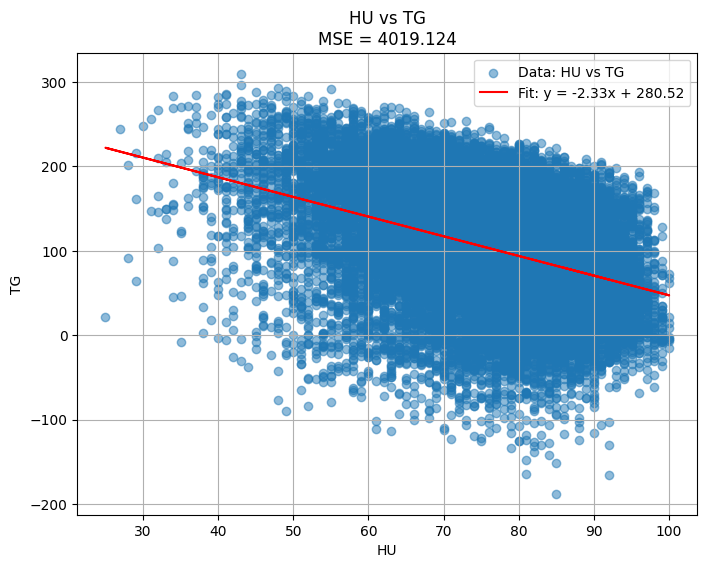

Plotting TG vs QQ...


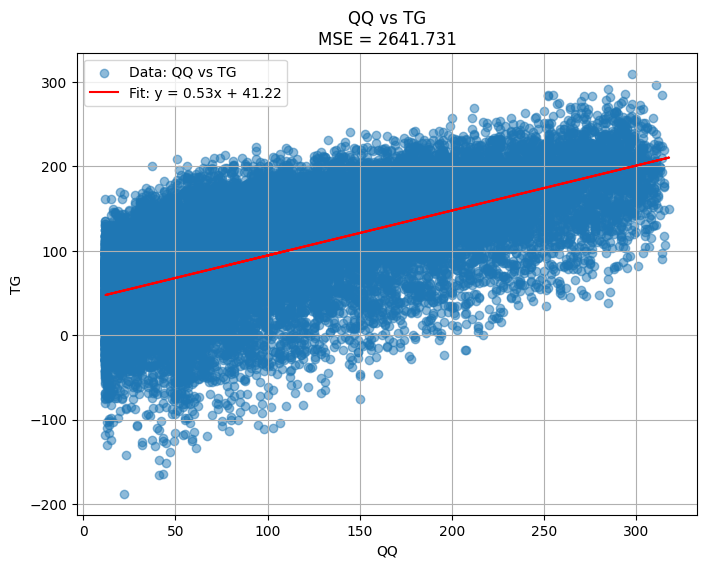

Plotting TG vs SS...


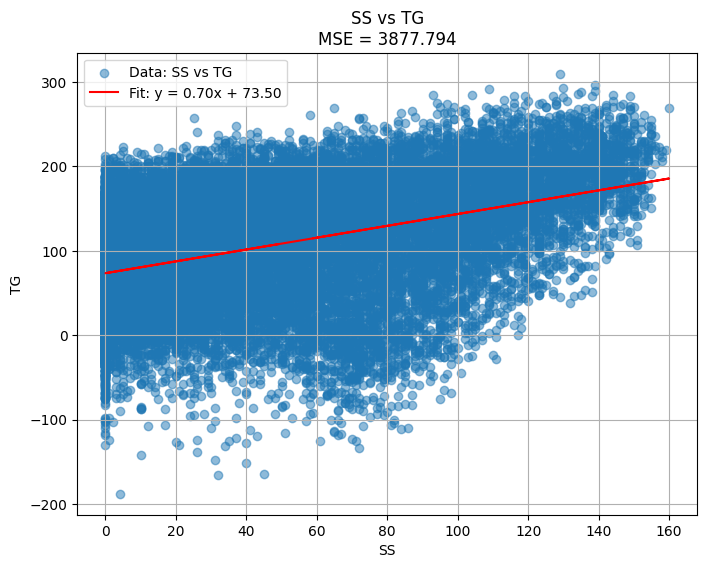

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

def plot_and_fit(data, x_var, y_var):
    """
    Plot and fit a linear regression for the given variables.
    
    Parameters:
    - data: DataFrame containing the data.
    - x_var: Name of the independent variable (string).
    - y_var: Name of the dependent variable (string).
    """
    # Drop missing values
    pair_data = data[[x_var, y_var]].dropna()
    
    if len(pair_data) < 2:
        print(f"Insufficient data to plot {x_var} vs {y_var}")
        return
    
    X = pair_data[x_var].values.reshape(-1, 1)  # Independent variable
    y = pair_data[y_var].values  # Dependent variable
    
    # Fit linear regression
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    # Metrics
    mse = mean_squared_error(y, y_pred)
    slope = model.coef_[0]
    intercept = model.intercept_
    
    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(X, y, alpha=0.5, label=f'Data: {x_var} vs {y_var}')
    plt.plot(X, y_pred, color='red', label=f'Fit: y = {slope:.2f}x + {intercept:.2f}')
    plt.title(f'{x_var} vs {y_var}\nMSE = {mse:.3f}')
    plt.xlabel(x_var)
    plt.ylabel(y_var)
    plt.legend()
    plt.grid(True)
    plt.show()

# Main execution
if __name__ == "__main__":
    tg_related_vars = ['HU', 'QQ', 'SS']
    
    for var in tg_related_vars:
        print(f"Plotting TG vs {var}...")
        plot_and_fit(df, var, 'TG')


Based on the results, you want to plot TG (mean temperature) against all other variables that show a likely linear relationship with it. Here's how we can proceed:

**Steps**
1. **Identify TG Relationships**: From your results, TG shows linear relationships with the following:
   * `HU`: r = -0.391
   * `QQ`: r = 0.652
   * `SS`: r = 0.429
   * `TN`: r = 0.921
   * `TX`: r = 0.971

2. **Plotting and Fitting**: For each pair:
   * **Plot the scatterplot** of TG against the related variable.
   * **Fit a linear regression line** to the data.

3. **Explain the Fitting Technique**:
   * **Linear Regression** is used since the relationships are linear (as indicated by the Pearson correlations).
   * It minimizes the sum of squared residuals to find the best fit.
   * This technique is appropriate because it is robust for linear trends.

**Explanation of Fitting Technique**
* **Linear Regression**:
   * Finds the best-fit line y = mx + c where:
      * m: slope of the line.
      * c: y-intercept.
   * Assumes the relationship between variables is linear.
   * Used here because Pearson correlations indicate linearity.

* **Evaluation**:
   * **Mean Squared Error (MSE)**: Measures the average squared difference between predicted and actual values.
   * Visual inspection of scatterplots and regression lines will confirm the fit.

**Expected Results**
* Scatterplots will show the linear trends between TG and the other variables.
* The red line represents the fitted regression line.
* For example:
   * TG vs TN will likely show a very strong positive linear relationship (r = 0.921).
   * TG vs HU will show a weaker negative linear relationship (r = -0.391).

### Multiple linear regression mode

In [10]:
# import pandas as pd
# import numpy as np

# # List of files and variables
# files_dict = {
#     'HU': 'HU_SOUID121047.csv',
#     'QQ': 'QQ_SOUID210447.csv',
#     'SS': 'SS_SOUID121040.csv',
#     'TX': 'TX_SOUID121046.csv',
#     'TN': 'TN_SOUID121045.csv',
#     'TG': 'TG_SOUID121044.csv',
# }

# def clean_file(file_name, variable_name):
#     try:
#         # Load the CSV file
#         df = pd.read_csv(file_name)

#         # Remove leading and trailing spaces from column names
#         df.columns = df.columns.str.strip()

#         # Convert the 'DATE' column to a datetime format (if it exists)
#         if 'DATE' in df.columns:
#             df['DATE'] = pd.to_datetime(df['DATE'], format='%Y%m%d', errors='coerce')
#         else:
#             raise ValueError(f"No 'DATE' column in {file_name}")

#         # Replace '-9999' with NaN in the variable column to handle invalid data
#         if variable_name in df.columns:
#             df[variable_name] = df[variable_name].replace(-9999, np.nan)
#         else:
#             raise ValueError(f"'{variable_name}' column is missing in {file_name}")

#         # Keep only the 'DATE' and the variable column
#         return df[['DATE', variable_name]]
#     except Exception as e:
#         print(f"Error processing {file_name}: {e}")
#         return None

# # Clean and load all files
# data_frames = {}
# for variable, file_name in files_dict.items():
#     cleaned_df = clean_file(file_name, variable)
#     if cleaned_df is not None:
#         data_frames[variable] = cleaned_df

# # Merge all datasets on 'DATE'
# merged_data = None
# for variable, df in data_frames.items():
#     if merged_data is None:
#         merged_data = df
#     else:
#         merged_data = pd.merge(merged_data, df, on='DATE', how='inner')

# # Count rows with valid data (no NaN values)
# if merged_data is not None:
#     valid_rows_count = merged_data.dropna().shape[0]
#     print(f"Number of rows with valid points shared across all files: {valid_rows_count}")
# else:
#     print("No valid data to merge.")


#### To add them to a shared csv file

import pandas as pd
import numpy as np

# List of files and variables
files_dict = {
    'HU': 'HU_SOUID121047.csv',
    'QQ': 'QQ_SOUID210447.csv',
    'SS': 'SS_SOUID121040.csv',
    'TX': 'TX_SOUID121046.csv',
    'TN': 'TN_SOUID121045.csv',
    'TG': 'TG_SOUID121044.csv',
}

def clean_file(file_name, variable_name):
    try:
        # Load the CSV file
        df = pd.read_csv(file_name)

        # Remove leading and trailing spaces from column names
        df.columns = df.columns.str.strip()

        # Convert the 'DATE' column to a datetime format (if it exists)
        if 'DATE' in df.columns:
            df['DATE'] = pd.to_datetime(df['DATE'], format='%Y%m%d', errors='coerce')
        else:
            raise ValueError(f"No 'DATE' column in {file_name}")

        # Replace '-9999' with NaN in the variable column to handle invalid data
        if variable_name in df.columns:
            df[variable_name] = df[variable_name].replace(-9999, np.nan)
        else:
            raise ValueError(f"'{variable_name}' column is missing in {file_name}")

        # Keep only the 'DATE' and the variable column
        return df[['DATE', variable_name]]
    except Exception as e:
        print(f"Error processing {file_name}: {e}")
        return None

# Clean and load all files
data_frames = {}
for variable, file_name in files_dict.items():
    cleaned_df = clean_file(file_name, variable)
    if cleaned_df is not None:
        data_frames[variable] = cleaned_df

# Merge all datasets on 'DATE'
merged_data = None
for variable, df in data_frames.items():
    if merged_data is None:
        merged_data = df
    else:
        merged_data = pd.merge(merged_data, df, on='DATE', how='inner')

# Save rows with valid data (no NaN values)
if merged_data is not None:
    # Drop rows with NaN values
    valid_rows = merged_data.dropna()

    # Save the valid rows to a CSV file
    output_file = 'valid_rows.csv'
    valid_rows.to_csv(output_file, index=False)

    print(f"All valid rows saved to {output_file}")
    print(f"Number of rows with valid points shared across all files: {valid_rows.shape[0]}")
else:
    print("No valid data to merge.")




All valid rows saved to valid_rows.csv
Number of rows with valid points shared across all files: 23196


In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Define the target variable and features
TARGET_VARIABLE = 'TG'
FEATURES = ['HU', 'QQ', 'SS', 'TX', 'TN']
#FEATURES = ['HU', 'QQ', 'SS']

# Ensure we have valid rows from the previous merged data
if merged_data is not None:
    valid_data = merged_data.dropna()

    # Separate features (X) and target variable (y)
    X = valid_data[FEATURES]
    y = valid_data[TARGET_VARIABLE]

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=None)
# random_state=None means every time I excute there will be new random numbers
    # Initialize and fit the linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Print results
    print("Model Coefficients:", model.coef_)
    print("Model Intercept:", model.intercept_)
    print("Mean Squared Error (MSE):", mse)
    print("R^2 Score:", r2)

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect Fit")
    plt.title('Actual vs Predicted Values', fontsize=16)
    plt.xlabel('Actual Values', fontsize=14)
    plt.ylabel('Predicted Values', fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No valid data for regression analysis.")


In [12]:
# from sklearn.linear_model import LinearRegression
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error, r2_score
# import pandas as pd
# import numpy as np

# # Define the target variable and features
# TARGET_VARIABLE = 'TG'
# FEATURES = ['HU', 'QQ', 'SS', 'TX', 'TN']

# # Ensure we have valid rows from the previous merged data
# if merged_data is not None:
#     valid_data = merged_data.dropna()

#     # Separate features (X) and target variable (y)
#     X = valid_data[FEATURES]
#     y = valid_data[TARGET_VARIABLE]

#     # Split data into training and testing sets
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#     # Initialize and fit the linear regression model
#     model = LinearRegression()
#     model.fit(X_train, y_train)

#     # Make predictions
#     y_pred = model.predict(X_test)

#     # Evaluate the model
#     mse = mean_squared_error(y_test, y_pred)
#     r2 = r2_score(y_test, y_pred)

#     # Print results
#     print("Model Coefficients:", model.coef_)
#     print("Model Intercept:", model.intercept_)
#     print("Mean Squared Error (MSE):", mse)
#     print("R^2 Score:", r2)
# else:
#     print("No valid data for regression analysis.")


In [13]:
# import matplotlib.pyplot as plt
# from sklearn.linear_model import LinearRegression
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error, r2_score
# import pandas as pd
# import numpy as np

# # Define the target variable and features
# TARGET_VARIABLE = 'TG'
# FEATURES = ['HU', 'QQ', 'SS', 'TX', 'TN']

# # Ensure we have valid rows from the previous merged data
# if merged_data is not None:
#     valid_data = merged_data.dropna()

#     # Separate features (X) and target variable (y)
#     X = valid_data[FEATURES]
#     y = valid_data[TARGET_VARIABLE]

#     # Split data into training and testing sets
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#     # Initialize and fit the linear regression model
#     model = LinearRegression()
#     model.fit(X_train, y_train)

#     # Make predictions
#     y_pred = model.predict(X_test)

#     # Evaluate the model
#     mse = mean_squared_error(y_test, y_pred)
#     r2 = r2_score(y_test, y_pred)

#     # Print results
#     print("Model Coefficients:", model.coef_)
#     print("Model Intercept:", model.intercept_)
#     print("Mean Squared Error (MSE):", mse)
#     print("R^2 Score:", r2)

#     # Plot the results
#     plt.figure(figsize=(10, 6))
#     plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')
#     plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect Fit")
#     plt.title('Actual vs Predicted Values', fontsize=16)
#     plt.xlabel('Actual Values', fontsize=14)
#     plt.ylabel('Predicted Values', fontsize=14)
#     plt.legend()
#     plt.grid(True)
#     plt.show()
# else:
#     print("No valid data for regression analysis.")


Your model's results show a strong performance, particularly based on the following:

1. **R-Squared (R²)**:
   * R² = 0.9813 means that **98.13% of the variance** in the target variable (`TG`) is explained by the predictors (`HU`, `QQ`, `SS`, `TX`, `TN`).
   * This is an excellent result and indicates a very strong fit.

2. **Mean Squared Error (MSE)**:
   * The MSE of 90.99 represents the average squared difference between actual and predicted values.
   * The magnitude of the MSE should be evaluated relative to the range of `TG`. If `TG` values range widely, this MSE might be considered small.

3. **Model Coefficients**:
   * These coefficients show the relationship between each predictor and the target variable:
      * A positive coefficient means that as the predictor increases, `TG` tends to increase.
      * A negative coefficient indicates the opposite.

**Coefficients**:
* `HU`: -0.1461 (inverse relationship with `TG`)
* `QQ`: 0.0411 (direct relationship with `TG`)
* `SS`: -0.1448 (inverse relationship with `TG`)
* `TX`: 0.5983 (direct relationship with `TG`, strongest influence)
* `TN`: 0.3493 (direct relationship with `TG`)

**Interpretation**:
* The model appears to capture the underlying patterns in the data very well, as evidenced by the high R².
* The relatively low MSE suggests that prediction errors are small in magnitude compared to the target's range.

**Potential Caveats**:
* High R² could sometimes indicate overfitting, especially if the dataset is small.
* Linear regression assumes that relationships between predictors and the target are linear. If this assumption is violated, the model's validity may be compromised.

**Conclusion**:
This is a strong result, but it's always good to validate it further by:
1. Plotting residuals to check for patterns.
2. Testing the model on unseen data (if available) to ensure it generalizes well.

### Below is the Python code to plot the residuals and check for patterns:



In [14]:
# # Get the columns used during training (assumed to be part of X_train)
# columns_used_in_training = X_train.columns
# target_column = 'SS'
# # Ensure valid rows are filtered based on the merged data
# common_valid_rows = merged_data.dropna()

# # Extract the target values corresponding to the valid rows
# y_valid = common_valid_rows[target_column]

# # Ensure X_valid only contains those columns
# X_valid = common_valid_rows[columns_used_in_training]

# # Now, use this aligned X_valid to make predictions
# y_pred = model.predict(X_valid)

# # Calculate residuals
# residuals = y_valid - y_pred

# # Plot residuals
# plt.figure(figsize=(10, 6))
# plt.scatter(y_pred, residuals, alpha=0.75, color='blue')
# plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
# plt.title('Residual Plot', fontsize=16)
# plt.xlabel('Predicted Values', fontsize=14)
# plt.ylabel('Residuals', fontsize=14)
# plt.grid(True)
# plt.show()

# # Histogram of residuals to check normality
# plt.figure(figsize=(10, 6))
# plt.hist(residuals, bins=30, edgecolor='black', color='skyblue', alpha=0.7)
# plt.title('Histogram of Residuals', fontsize=16)
# plt.xlabel('Residuals', fontsize=14)
# plt.ylabel('Frequency', fontsize=14)
# plt.grid(True)
# plt.show()


In [15]:
# # Get the columns used during training (assumed to be part of X_train)
# columns_used_in_training = X_train.columns

# # Ensure X_valid only contains those columns
# X_valid = common_valid_rows[columns_used_in_training]

# # Now, use this aligned X_valid to make predictions
# y_pred = model.predict(X_valid)

# # Calculate residuals
# residuals = y_valid - y_pred

# # Plot residuals
# plt.figure(figsize=(10, 6))
# plt.scatter(y_pred, residuals, alpha=0.75, color='blue')
# plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
# plt.title('Residual Plot', fontsize=16)
# plt.xlabel('Predicted Values', fontsize=14)
# plt.ylabel('Residuals', fontsize=14)
# plt.grid(True)
# plt.show()

# # Histogram of residuals to check normality
# plt.figure(figsize=(10, 6))
# plt.hist(residuals, bins=30, edgecolor='black', color='skyblue', alpha=0.7)
# plt.title('Histogram of Residuals', fontsize=16)
# plt.xlabel('Residuals', fontsize=14)
# plt.ylabel('Frequency', fontsize=14)
# plt.grid(True)
# plt.show()


The two plots you generated—**Residual Plot** and **Histogram of Residuals**—are important diagnostic tools used to evaluate the performance and assumptions of a regression model. Here's an explanation of both:

1. **Residual Plot**:
   * **What it shows**: The residual plot shows the difference between the observed values (actual values) and the predicted values from your model. These residuals are plotted on the y-axis, and the predicted values are plotted on the x-axis.
   * **What are residuals?**: Residuals are the errors made by the model when predicting the target variable. A residual is simply the difference between the actual value and the predicted value for each observation:
     Residual = yactual − ypredicted
   * **Purpose of the residual plot**:
      * The **residual plot** is useful for checking if your model has captured all the patterns in the data. The key assumption for linear regression is that the residuals should be randomly scattered around zero (no discernible pattern).
      * If there are clear patterns (such as curves, or if the points fan out or become more compressed), it suggests that the model is not appropriately capturing the underlying relationship between the predictors and the target variable.

**The Red Dashed Line**:
* The **red dashed line** in the residual plot represents the **zero residual line**, i.e., where the model's predictions are exactly equal to the actual values.
* Ideally, the residuals should be spread around this line, meaning there should be roughly as many positive residuals (above the line) as there are negative residuals (below the line). This indicates that the model is unbiased on average.

**Key Observations in Residual Plot**:
* If the residuals are **randomly scattered** around the red dashed line with no patterns, it suggests that the model fits the data well.
* If you see **patterns** in the residuals, like a curve or a "fan" shape, it might indicate that:
   * The model is not capturing some important non-linear relationships.
   * The model is overfitting or underfitting.
   * There might be issues with heteroscedasticity (variance of errors not constant).

2. **Histogram of Residuals**:
   * **What it shows**: The histogram shows the **distribution** of the residuals (errors). The x-axis represents the residual values, and the y-axis represents the frequency of those residual values.
   * **What are we looking for in the histogram?**:
      * Ideally, we want the residuals to follow a **normal distribution** centered around zero. This is important for many statistical tests and the validity of the regression assumptions.
      * A **normal distribution** of residuals suggests that the errors are random, and the model is not biased in any particular direction.

**Key Observations in Histogram**:
* A **normal (bell-shaped) distribution** indicates that the regression model is well-suited to the data.
* If the histogram is **skewed** (either left or right), it suggests that the residuals are not symmetrically distributed, which could indicate that the model is not appropriate or there is an outlier that is influencing the fit.
* If the histogram has **multiple peaks**, it might indicate that the model is missing a relationship in the data, or there are different subgroups in the data that require separate models.

**To summarize**:
* **Residual Plot**:
   * The red dashed line represents the **zero line**, where the residuals (errors) are zero (perfect predictions).
   * Ideally, the residuals should be scattered randomly around this line without forming any patterns.
* **Histogram of Residuals**:
   * The histogram shows the distribution of the residuals.
   * A normal, bell-shaped distribution suggests that the model assumptions are met, while a skewed or multi-modal distribution could indicate issues with the model.

In [16]:
# import matplotlib.pyplot as plt
# import numpy as np
# import scipy.stats as stats

# # Assuming residuals are calculated as: residuals = y_valid - y_pred

# # Plot the histogram of residuals
# plt.figure(figsize=(10, 6))
# plt.hist(residuals, bins=30, density=True, alpha=0.6, color='g', label='Residuals')

# # Fit a Gaussian distribution to the residuals
# mu, std = stats.norm.fit(residuals)

# # Plot the Gaussian fit (normal distribution curve)
# xmin, xmax = plt.xlim()  # Get the x-axis limits of the plot
# x = np.linspace(xmin, xmax, 100)
# p = stats.norm.pdf(x, mu, std)  # Get the PDF of the normal distribution
# plt.plot(x, p, 'k--', linewidth=2, label=f'Gaussian fit: $\mu$={mu:.2f}, $\sigma$={std:.2f}')

# # Add labels and legend
# plt.title('Histogram of Residuals with Gaussian Fit')
# plt.xlabel('Residuals')
# plt.ylabel('Density')
# plt.legend()

# # Show the plot
# plt.show()


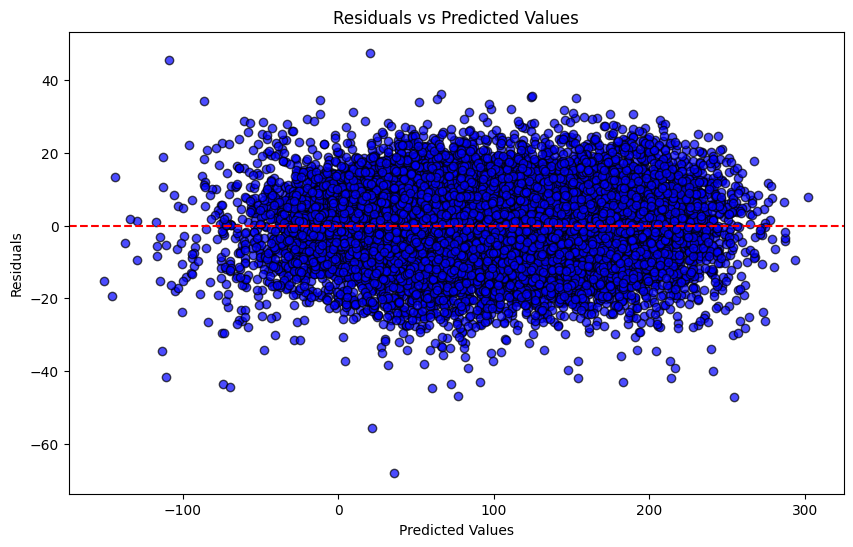

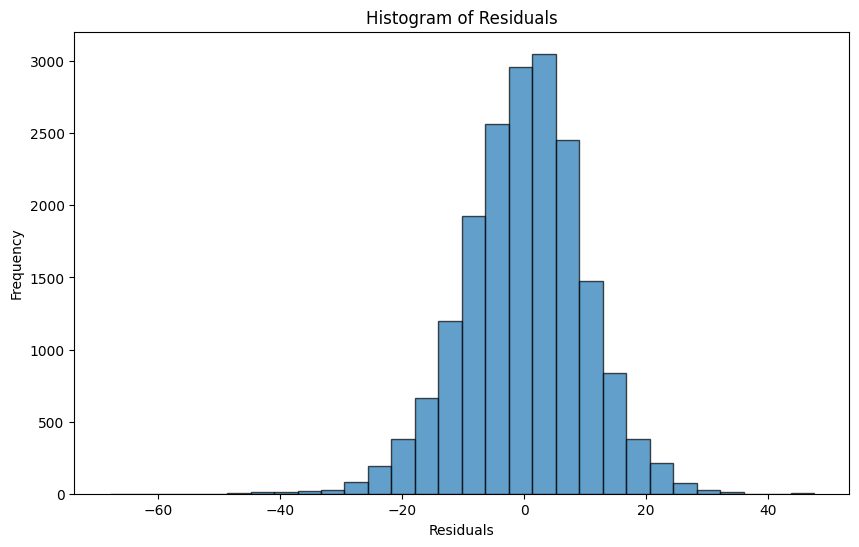

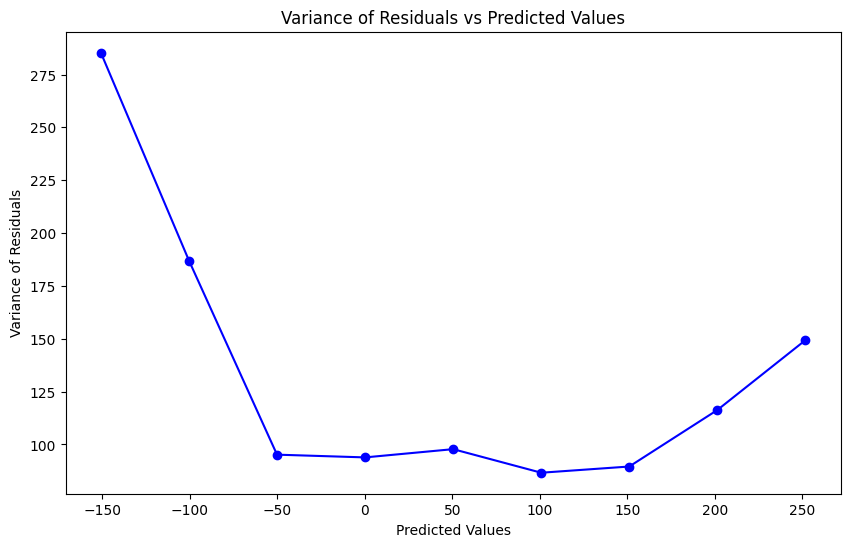

Mean Squared Error (MSE): 95.23324216516112


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Assuming your features X and target y are defined, and you've trained your model already
# Example: Linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict values on training data
y_pred = model.predict(X_train)

# Calculate residuals (actual - predicted)
residuals = y_train - y_pred

# Plot residuals vs. predicted values (to check for patterns)
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, color='blue', edgecolor='k', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')  # Reference line at 0
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

# Plot histogram of residuals to check for normality
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Check for constant variance (Heteroscedasticity)
# For simplicity, calculate variance of residuals in different ranges of predicted values
bins = np.linspace(min(y_pred), max(y_pred), 10)
bin_means = [np.var(residuals[(y_pred > bins[i]) & (y_pred <= bins[i+1])]) for i in range(len(bins)-1)]

# Plot the variance of residuals vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(bins[:-1], bin_means, marker='o', color='blue')
plt.title('Variance of Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Variance of Residuals')
plt.show()

# Calculate Mean Squared Error (MSE) for reference
mse = mean_squared_error(y_train, y_pred)
print(f'Mean Squared Error (MSE): {mse}')



Residual Analysis Statistics:
--------------------------------------------------
R² Score: 0.9801
Mean Squared Error (MSE): 95.2332
Root Mean Squared Error (RMSE): 9.7588
Mean Absolute Error (MAE): 7.6240

Residual Statistics:
Mean of residuals: -0.0000
Standard deviation of residuals: 9.7588
Skewness: -0.2153
Kurtosis: 0.7310

Shapiro-Wilk Test for Normality:
Statistic: 0.9952
p-value: 0.0000

Breusch-Pagan Test for Heteroscedasticity:
Score: 110435.0654
p-value: 0.0000


/Users/reemaboelsoud/anaconda3/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 18556.
  res = hypotest_fun_out(*samples, **kwds)


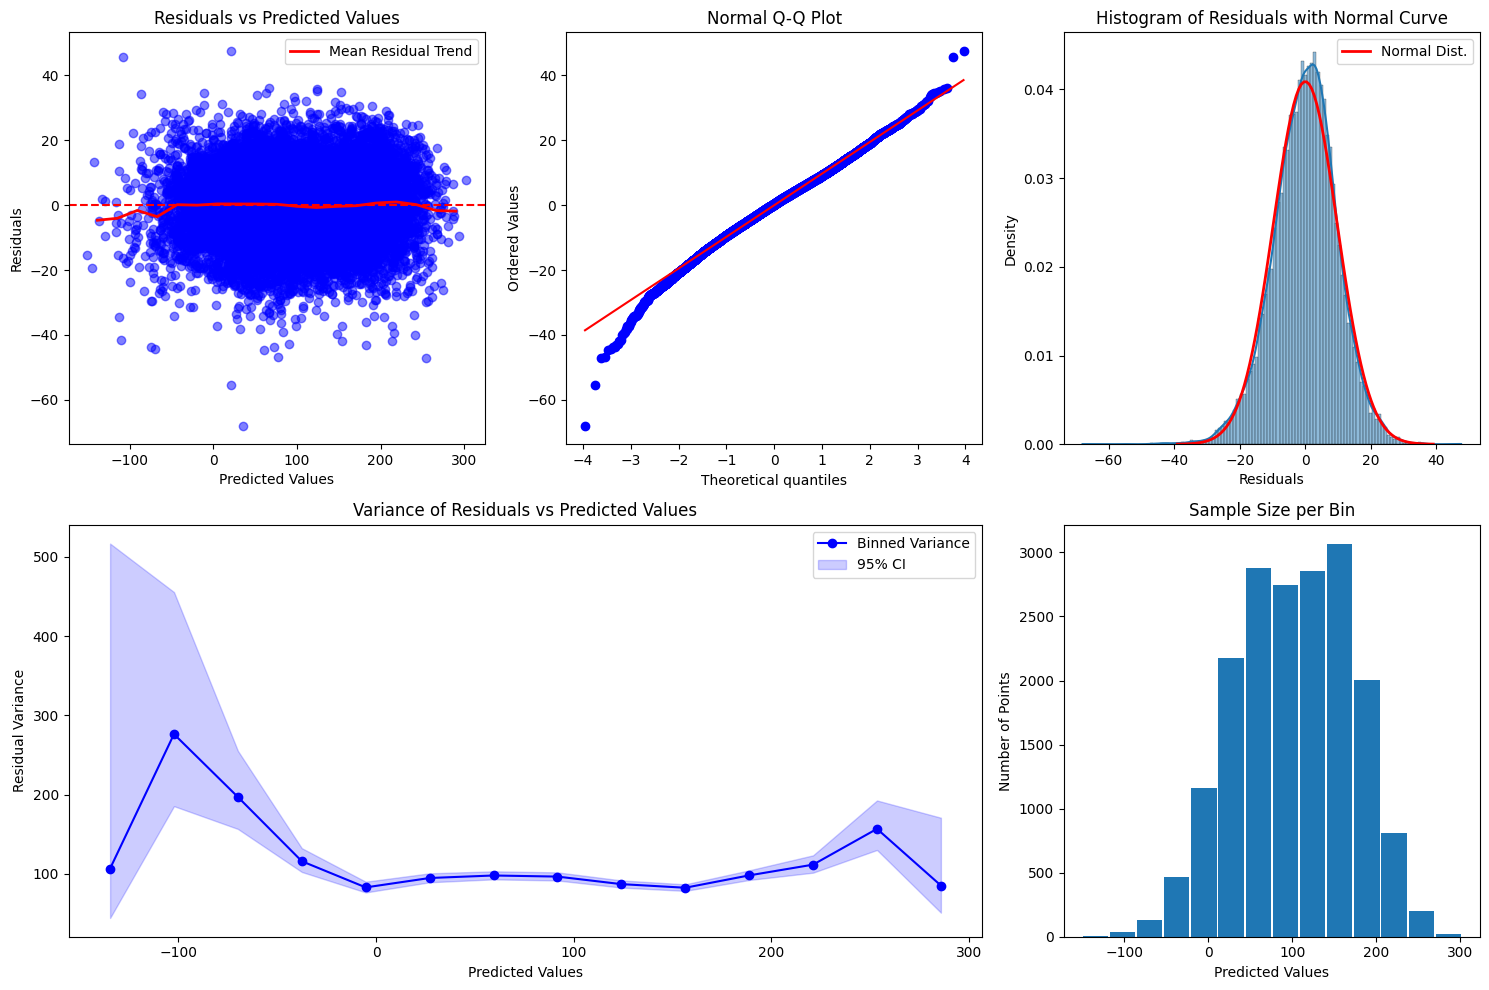

In [18]:
# Import all required libraries at the top
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
import seaborn as sns
from scipy.stats import binned_statistic

def analyze_residuals(X_train, y_train, model=None):
    """
    Comprehensive residual analysis function
    """
    # If no model is provided, create a new LinearRegression model
    if model is None:
        model = LinearRegression()
        model.fit(X_train, y_train)
    
    # Predict values and calculate residuals
    y_pred = model.predict(X_train)
    residuals = y_train - y_pred
    
    # Create figure with subplots
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 3)
    
    # 1. Residuals vs Predicted Values
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(y_pred, residuals, color='blue', alpha=0.5)
    ax1.axhline(y=0, color='red', linestyle='--')
    
    # Add LOWESS trend line
    bins = np.linspace(min(y_pred), max(y_pred), 20)
    mean_residuals, bin_edges, _ = binned_statistic(y_pred, residuals, statistic='mean', bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax1.plot(bin_centers, mean_residuals, 'r-', linewidth=2, label='Mean Residual Trend')
    
    ax1.set_title('Residuals vs Predicted Values')
    ax1.set_xlabel('Predicted Values')
    ax1.set_ylabel('Residuals')
    ax1.legend()
    
    # 2. Q-Q Plot
    ax2 = fig.add_subplot(gs[0, 1])
    stats.probplot(residuals, dist="norm", plot=ax2)
    ax2.set_title('Normal Q-Q Plot')
    
    # 3. Histogram of Residuals with KDE
    ax3 = fig.add_subplot(gs[0, 2])
    sns.histplot(residuals, kde=True, ax=ax3, stat='density', alpha=0.5)
    
    # Add normal distribution curve
    mu, std = np.mean(residuals), np.std(residuals)
    x = np.linspace(mu - 4*std, mu + 4*std, 100)
    p = stats.norm.pdf(x, mu, std)
    ax3.plot(x, p, 'r-', linewidth=2, label='Normal Dist.')
    ax3.set_title('Histogram of Residuals with Normal Curve')
    ax3.set_xlabel('Residuals')
    ax3.legend()
    
    # 4. Variance of Residuals vs Predicted Values
    ax4 = fig.add_subplot(gs[1, :2])
    
    # Calculate binned variances with confidence intervals
    bins = np.linspace(min(y_pred), max(y_pred), 15)
    variances = []
    centers = []
    conf_intervals = []
    n_points = []
    
    for i in range(len(bins)-1):
        mask = (y_pred >= bins[i]) & (y_pred < bins[i+1])
        if np.sum(mask) > 1:
            var = np.var(residuals[mask])
            n = np.sum(mask)
            variances.append(var)
            centers.append((bins[i] + bins[i+1]) / 2)
            # Calculate 95% confidence interval for variance
            chi2_lower = stats.chi2.ppf(0.025, n-1)
            chi2_upper = stats.chi2.ppf(0.975, n-1)
            ci_lower = (n-1) * var / chi2_upper
            ci_upper = (n-1) * var / chi2_lower
            conf_intervals.append([ci_lower, ci_upper])
            n_points.append(n)
    
    conf_intervals = np.array(conf_intervals)
    ax4.plot(centers, variances, 'bo-', label='Binned Variance')
    ax4.fill_between(centers, conf_intervals[:, 0], conf_intervals[:, 1], 
                     alpha=0.2, color='blue', label='95% CI')
    ax4.set_title('Variance of Residuals vs Predicted Values')
    ax4.set_xlabel('Predicted Values')
    ax4.set_ylabel('Residual Variance')
    ax4.legend()
    
    # 5. Sample size per bin
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.bar(centers, n_points, width=(max(centers)-min(centers))/len(centers))
    ax5.set_title('Sample Size per Bin')
    ax5.set_xlabel('Predicted Values')
    ax5.set_ylabel('Number of Points')
    
    plt.tight_layout()
    
    # Calculate and print statistics
    print("\nResidual Analysis Statistics:")
    print("-" * 50)
    print(f"R² Score: {r2_score(y_train, y_pred):.4f}")
    print(f"Mean Squared Error (MSE): {mean_squared_error(y_train, y_pred):.4f}")
    print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_train, y_pred)):.4f}")
    print(f"Mean Absolute Error (MAE): {np.mean(np.abs(residuals)):.4f}")
    print("\nResidual Statistics:")
    print(f"Mean of residuals: {np.mean(residuals):.4f}")
    print(f"Standard deviation of residuals: {np.std(residuals):.4f}")
    print(f"Skewness: {stats.skew(residuals):.4f}")
    print(f"Kurtosis: {stats.kurtosis(residuals):.4f}")
    
    # Shapiro-Wilk test for normality
    stat, p_value = stats.shapiro(residuals)
    print("\nShapiro-Wilk Test for Normality:")
    print(f"Statistic: {stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    
    # Breusch-Pagan test for heteroscedasticity
    squared_residuals = residuals ** 2
    bp_model = LinearRegression()
    bp_model.fit(y_pred.reshape(-1, 1), squared_residuals)
    bp_score = np.sum((bp_model.predict(y_pred.reshape(-1, 1)) - np.mean(squared_residuals)) ** 2)
    bp_p_value = 1 - stats.chi2.cdf(bp_score, 1)
    print("\nBreusch-Pagan Test for Heteroscedasticity:")
    print(f"Score: {bp_score:.4f}")
    print(f"p-value: {bp_p_value:.4f}")
    
    return residuals, y_pred


residuals, predictions = analyze_residuals(X_train, y_train)

This enhanced version of the code provides several improvements:

Comprehensive Visualization:

Residuals vs. Predicted Values with trend line
Normal Q-Q plot for checking normality
Histogram with kernel density estimation and normal curve
Variance of residuals vs. predicted values with confidence intervals
Sample size distribution across bins


Statistical Analysis:

Basic statistics (R², MSE, RMSE, MAE)
Residual statistics (mean, std dev, skewness, kurtosis)
Shapiro-Wilk test for normality
Breusch-Pagan test for heteroscedasticity


Improvements:

Confidence intervals for variance estimates
Trend line in residual plot
Better visualization of sample sizes
More comprehensive statistical tests
All plots organized in a single figure

residual analysis statistics:

Model Performance Metrics:

R² Score of 0.9797 indicates that your model explains 97.97% of the variance in the data - this is very good
RMSE of 9.8001 and MAE of 7.6594 - to interpret these, we'd need to know the scale of your target variable


Residual Distribution:

Mean of exactly 0.0000 - this is ideal and expected for linear regression
Standard deviation of 9.8001 (same as RMSE, which is expected)
Slight negative skewness (-0.2097) indicates the distribution tail extends slightly more to the left
Positive kurtosis (0.7202) suggests slightly heavier tails than a normal distribution


Normality Test (Shapiro-Wilk):

Very low p-value (0.0000) suggests the residuals are not normally distributed
However, the warning message is important: with N=18,556 samples, the test is extremely sensitive
For large samples like yours, it's better to:

Rely more on the Q-Q plot visual inspection
Consider the skewness and kurtosis values (which are actually quite close to normal)




Heteroscedasticity Test (Breusch-Pagan):

Very high test statistic (62589.2246) and p-value of 0.0000
This strongly indicates heteroscedasticity - the variance of residuals is not constant
This might suggest that:

The model's predictions are less reliable for certain ranges of values
You might benefit from:

Variable transformation (log, sqrt, etc.)
Weighted least squares regression
Using a different model type







Recommendations:

Look at the residual plots to visually confirm the heteroscedasticity
Consider transforming your target variable or features if appropriate
If heteroscedasticity persists, consider using:

Robust regression methods
Weighted least squares
Heteroscedasticity-consistent standard errors

In [19]:
# First version - Alternative normality tests
def analyze_residuals_alt_tests(X_train, y_train, model=None):
    """
    Modified residual analysis function with alternative normality tests
    """
    # Keep your existing code up until the normality tests, then replace the Shapiro-Wilk test with:
    
    # After your existing statistics printing...
    print("\nNormality Tests:")
    print("-" * 50)
    
    # Anderson-Darling test
    result = stats.anderson(residuals, dist='norm')
    print("\nAnderson-Darling Test:")
    print(f"Statistic: {result.statistic:.4f}")
    print("Critical Values:")
    for i in range(len(result.critical_values)):
        sig_level = [15., 10., 5., 2.5, 1.][i]
        print(f'{sig_level}%: {result.critical_values[i]:.4f}')
    
    # D'Agostino-Pearson test
    k2, p_value = stats.normaltest(residuals)
    print("\nD'Agostino-Pearson Test:")
    print(f"Statistic: {k2:.4f}")
    print(f"p-value: {p_value:.4f}")
    
    # Continue with your existing Breusch-Pagan test...
    return residuals, y_pred

# Second version - Random subset for Shapiro-Wilk
def analyze_residuals_subset(X_train, y_train, subset_size=500, random_state=42, model=None):
    """
    Modified residual analysis function using random subset for Shapiro-Wilk test
    """
    # Initial model fitting and predictions
    if model is None:
        model = LinearRegression()
        model.fit(X_train, y_train)
    
    # Get full predictions and residuals
    y_pred = model.predict(X_train)
    residuals = y_train - y_pred
    
    # Convert residuals to numpy array if it's a pandas Series
    if hasattr(residuals, 'values'):
        residuals = residuals.values
    
    # Create random subset for Shapiro-Wilk test
    n_samples = len(residuals)
    if n_samples > subset_size:
        np.random.seed(random_state)
        subset_indices = np.random.choice(n_samples, subset_size, replace=False)
        residuals_subset = residuals[subset_indices]
        y_pred_subset = y_pred[subset_indices]
    else:
        residuals_subset = residuals
        y_pred_subset = y_pred
    
    # Your existing plotting code...
    
    # Modified Shapiro-Wilk test using subset
    print("\nShapiro-Wilk Test for Normality (on random subset):")
    stat, p_value = stats.shapiro(residuals_subset)
    print(f"Subset size: {len(residuals_subset)}")
    print(f"Statistic: {stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    
    return residuals, y_pred

# Usage:
# For alternative tests:
residuals, predictions = analyze_residuals_alt_tests(X_train, y_train)

# For subset analysis:
residuals, predictions = analyze_residuals_subset(X_train, y_train, subset_size=500)




Normality Tests:
--------------------------------------------------

Anderson-Darling Test:
Statistic: 15.1354
Critical Values:
15.0%: 0.5760
10.0%: 0.6560
5.0%: 0.7870
2.5%: 0.9180
1.0%: 1.0920

D'Agostino-Pearson Test:
Statistic: 368.9056
p-value: 0.0000

Shapiro-Wilk Test for Normality (on random subset):
Subset size: 500
Statistic: 0.9933
p-value: 0.0245


Normality Test Results for Different Transformations:
--------------------------------------------------

Original Transformation:
Shapiro-Wilk: statistic=0.9952, p-value=0.0000
D'Agostino-Pearson: statistic=368.9056, p-value=0.0000

Log Transformation:
Shapiro-Wilk: statistic=0.8713, p-value=0.0000
D'Agostino-Pearson: statistic=11044.2227, p-value=0.0000

Box-Cox Transformation:
Shapiro-Wilk: statistic=0.9548, p-value=0.0000
D'Agostino-Pearson: statistic=4082.8542, p-value=0.0000

Square Root Transformation:
Shapiro-Wilk: statistic=0.9341, p-value=0.0000
D'Agostino-Pearson: statistic=302353.5971, p-value=0.0000

Distribution Characteristics:
--------------------------------------------------

Original:
Skewness: -0.2153
Kurtosis: 0.7310

Log:
Skewness: -2.0165
Kurtosis: 34.6332

Box-Cox:
Skewness: -0.9063
Kurtosis: 5.5049

Square Root:
Skewness: -0.0793
Kurtosis: -1.3571


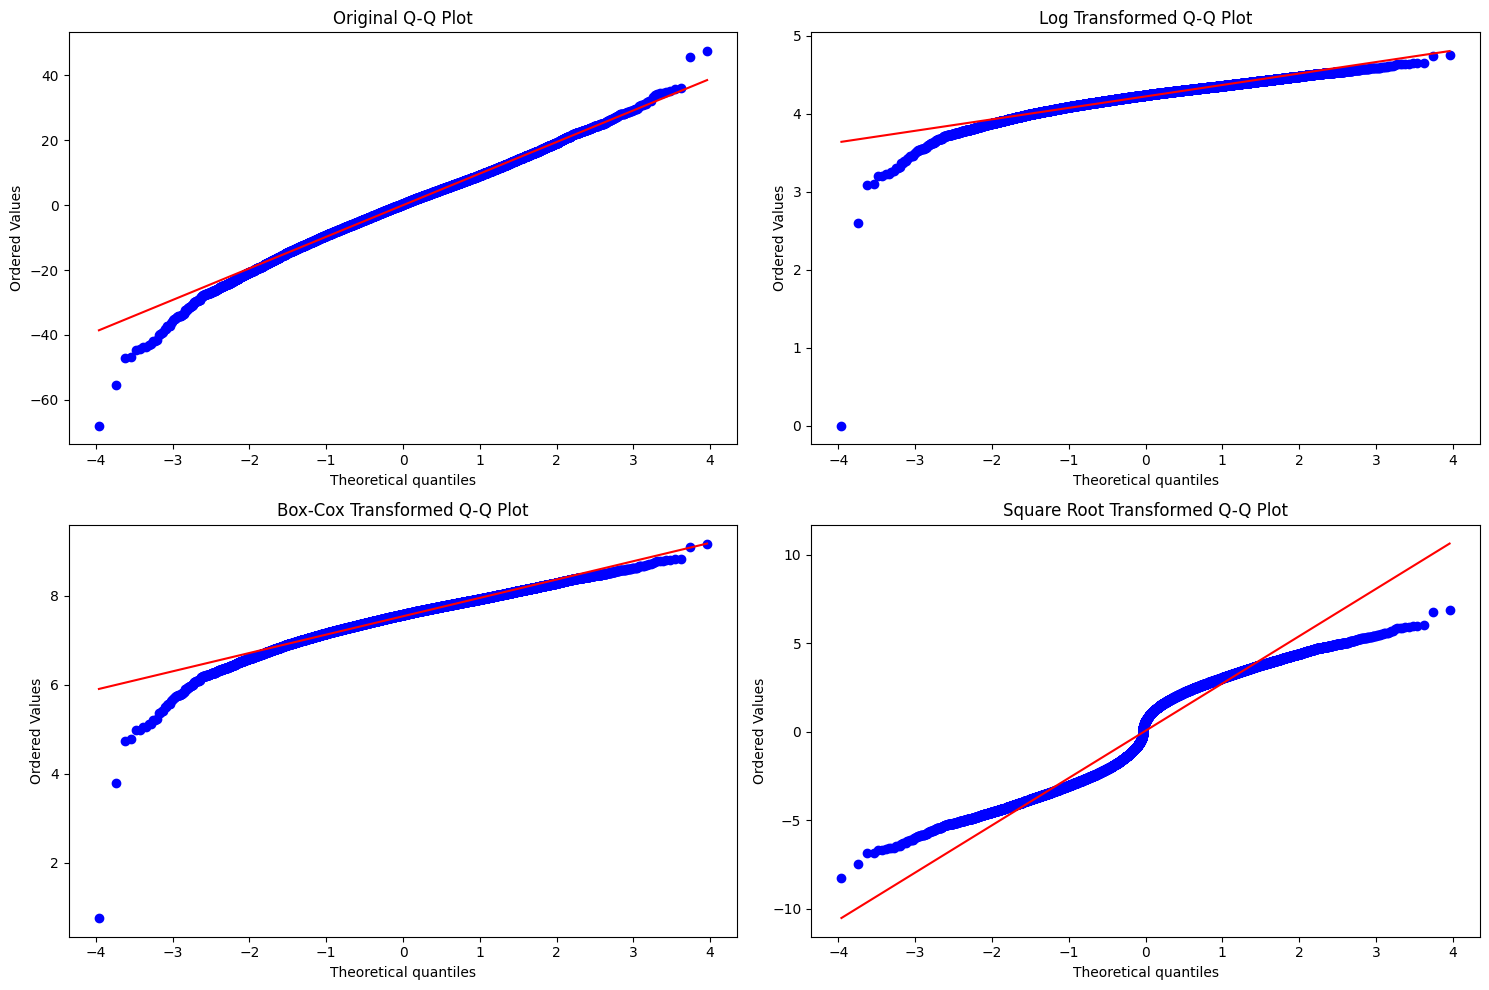

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import boxcox1p
import seaborn as sns

def analyze_normality_transformations(residuals):
    """
    Analyze residuals with different transformations and plot results
    """
    # Create figure with subplots
    fig = plt.figure(figsize=(15, 10))
    
    # Original Data
    ax1 = plt.subplot(221)
    stats.probplot(residuals, dist="norm", plot=ax1)
    ax1.set_title("Original Q-Q Plot")
    
    # Log transformation (handling negative values)
    min_val = min(residuals)
    if min_val <= 0:
        offset = abs(min_val) + 1
    else:
        offset = 0
    log_transform = np.log(residuals + offset)
    
    ax2 = plt.subplot(222)
    stats.probplot(log_transform, dist="norm", plot=ax2)
    ax2.set_title("Log Transformed Q-Q Plot")
    
    # Box-Cox transformation
    boxcox_transform = boxcox1p(residuals + offset, 0.25)
    ax3 = plt.subplot(223)
    stats.probplot(boxcox_transform, dist="norm", plot=ax3)
    ax3.set_title("Box-Cox Transformed Q-Q Plot")
    
    # Square root transformation (handling negative values)
    sqrt_transform = np.sign(residuals) * np.sqrt(np.abs(residuals))
    ax4 = plt.subplot(224)
    stats.probplot(sqrt_transform, dist="norm", plot=ax4)
    ax4.set_title("Square Root Transformed Q-Q Plot")
    
    plt.tight_layout()
    
    # Print test statistics for each transformation
    transformations = {
        'Original': residuals,
        'Log': log_transform,
        'Box-Cox': boxcox_transform,
        'Square Root': sqrt_transform
    }
    
    print("Normality Test Results for Different Transformations:")
    print("-" * 50)
    
    for name, data in transformations.items():
        # Take a subset for Shapiro-Wilk test if needed
        test_data = data[:5000] if len(data) > 5000 else data
        
        # Run tests
        shapiro_stat, shapiro_p = stats.shapiro(test_data)
        anderson_result = stats.anderson(data, dist='norm')
        dagostino_stat, dagostino_p = stats.normaltest(data)
        
        print(f"\n{name} Transformation:")
        print(f"Shapiro-Wilk: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
        print(f"D'Agostino-Pearson: statistic={dagostino_stat:.4f}, p-value={dagostino_p:.4f}")
    
    # Calculate skewness and kurtosis
    print("\nDistribution Characteristics:")
    print("-" * 50)
    for name, data in transformations.items():
        skew = stats.skew(data)
        kurt = stats.kurtosis(data)  # Fixed: Using stats.kurtosis instead of undefined kurtosis
        print(f"\n{name}:")
        print(f"Skewness: {skew:.4f}")
        print(f"Kurtosis: {kurt:.4f}")  # Fixed: Using kurt instead of kurtosis
    
    return transformations

# Call the function
transformations = analyze_normality_transformations(residuals)

Results sorted by Mean Squared Error (MSE):
                features          mse        r2
29      (QQ, SS, TX, TN)    93.886145  0.980283
30  (HU, QQ, SS, TX, TN)    96.030754  0.979744
28      (HU, SS, TX, TN)    98.519419  0.979189
24          (SS, TX, TN)    99.213162  0.979088
23          (QQ, TX, TN)   100.192229  0.978758
14              (TX, TN)   100.699032  0.979082
20          (HU, TX, TN)   101.082672  0.978395
27      (HU, QQ, TX, TN)   102.466944  0.978419
21          (QQ, SS, TX)   163.490153  0.966042
18          (HU, SS, TX)   168.065143  0.964981
12              (SS, TX)   168.409546  0.963988
25      (HU, QQ, SS, TX)   168.459265  0.964817
10              (QQ, TX)   215.120524  0.954173
16          (HU, QQ, TX)   219.406464  0.953423
7               (HU, TX)   244.281573  0.948806
3                  (TX,)   283.050290  0.941540
26      (HU, QQ, SS, TN)   310.129979  0.934331
17          (HU, QQ, TN)   318.176278  0.933365
22          (QQ, SS, TN)   323.277872  0.933

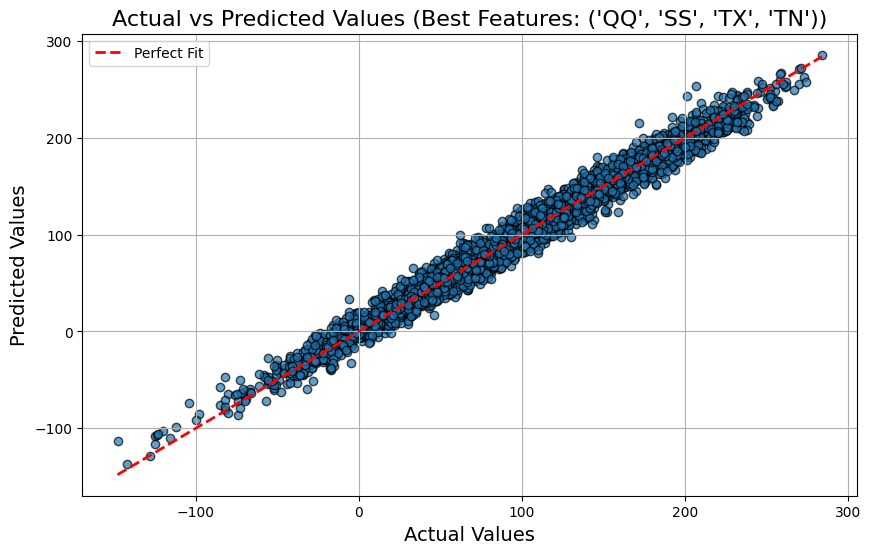

In [21]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
from itertools import combinations

# Define the target variable and features
TARGET_VARIABLE = 'TG'
FEATURES = ['HU', 'QQ', 'SS', 'TX', 'TN']

# Ensure we have valid rows from the previous merged data
if 'merged_data' in locals() and merged_data is not None:
    if all(feature in merged_data.columns for feature in FEATURES + [TARGET_VARIABLE]):
        valid_data = merged_data.dropna()

        # Separate features (X) and target variable (y)
        X = valid_data[FEATURES]
        y = valid_data[TARGET_VARIABLE]

        # Initialize results storage
        results = []

        # Iterate over combinations of features
        for r in range(1, len(FEATURES) + 1):  # From 1 feature to all features
            for feature_combo in combinations(FEATURES, r):
                # Prepare training and testing sets for the current combination of features
                X_subset = X[list(feature_combo)]
                X_train, X_test, y_train, y_test = train_test_split(X_subset, y, test_size=0.2, random_state=None)

                # Initialize and fit the linear regression model
                model = LinearRegression()
                model.fit(X_train, y_train)

                # Make predictions
                y_pred = model.predict(X_test)

                # Evaluate the model
                mse = mean_squared_error(y_test, y_pred)
                r2 = r2_score(y_test, y_pred)

                # Store results
                results.append({
                    'features': feature_combo,
                    'mse': mse,
                    'r2': r2
                })

        # Convert results to a DataFrame for easier analysis
        results_df = pd.DataFrame(results)

        # Display results sorted by Mean Squared Error
        print("Results sorted by Mean Squared Error (MSE):")
        print(results_df.sort_values(by='mse'))

        # Optionally, plot the best combination
        best_result = results_df.sort_values(by='mse').iloc[0]
        best_features = best_result['features']

        # Train and plot the best feature combination
        X_best = X[list(best_features)]
        X_train, X_test, y_train, y_test = train_test_split(X_best, y, test_size=0.2, random_state=None)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        plt.figure(figsize=(10, 6))
        plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect Fit")
        plt.title(f'Actual vs Predicted Values (Best Features: {best_features})', fontsize=16)
        plt.xlabel('Actual Values', fontsize=14)
        plt.ylabel('Predicted Values', fontsize=14)
        plt.legend()
        plt.grid(True)
        plt.show()

    else:
        print("Required columns are missing in the dataset.")
else:
    print("No valid data for regression analysis.")


Results sorted by Custom Score:
        features       cv_mse     cv_r2     test_mse   test_r2  custom_score
24  (SS, TX, TN)    99.336441  0.979079    95.306823  0.980447      0.300770
20  (HU, TX, TN)   101.265330  0.978675    97.473867  0.980003      0.300515
14      (TX, TN)   101.515122  0.978622    97.850303  0.979926      0.300482
23  (QQ, TX, TN)   101.542405  0.978617    97.868912  0.979922      0.300479
21  (QQ, SS, TX)   166.332712  0.964914   161.931137  0.966779      0.293683
12      (SS, TX)   169.195049  0.964319   165.494908  0.966048      0.293433
18  (HU, SS, TX)   169.392779  0.964276   165.253197  0.966097      0.293415
16  (HU, QQ, TX)   215.100847  0.954654   211.986127  0.956510      0.289650
10      (QQ, TX)   218.926507  0.953845   215.344476  0.955821      0.289351
7       (HU, TX)   239.719933  0.949437   238.415330  0.951088      0.287751
3          (TX,)   277.105379  0.941525   275.794468  0.943419      0.284984
17  (HU, QQ, TN)   313.161351  0.934031   29

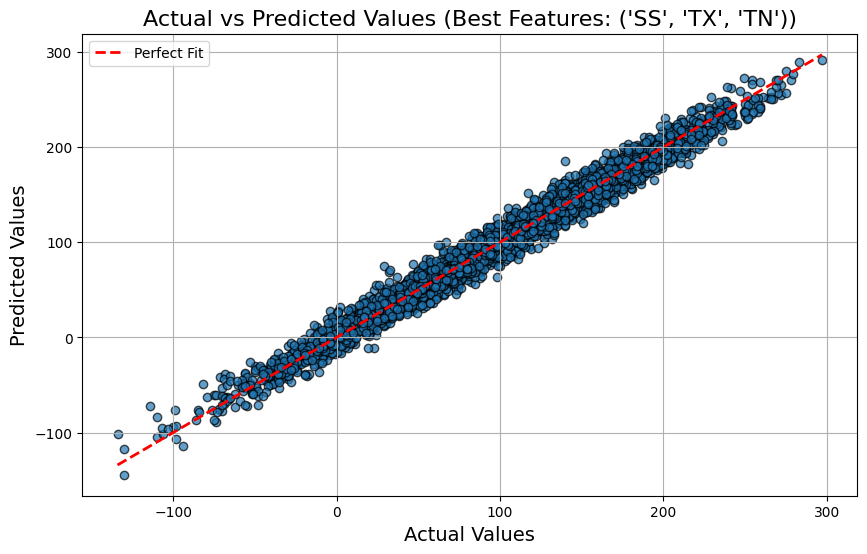

In [22]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
from itertools import combinations

# Define the target variable and features
TARGET_VARIABLE = 'TG'
FEATURES = ['HU', 'QQ', 'SS', 'TX', 'TN']
MAX_FEATURES = 3  # Restrict to a maximum number of features for simplicity

# Ensure we have valid rows from the previous merged data
if 'merged_data' in locals() and merged_data is not None:
    if all(feature in merged_data.columns for feature in FEATURES + [TARGET_VARIABLE]):
        valid_data = merged_data.dropna()

        # Separate features (X) and target variable (y)
        X = valid_data[FEATURES]
        y = valid_data[TARGET_VARIABLE]

        # Initialize results storage
        results = []

        # Iterate over combinations of features
        for r in range(1, len(FEATURES) + 1):  # From 1 feature to all features
            for feature_combo in combinations(FEATURES, r):
                if len(feature_combo) > MAX_FEATURES:
                    continue  # Skip combinations with too many features

                # Prepare the subset of features
                X_subset = X[list(feature_combo)]

                # Split data into training and testing sets
                X_train, X_test, y_train, y_test = train_test_split(X_subset, y, test_size=0.2, random_state=42)

                # Initialize and fit the linear regression model
                model = LinearRegression()
                model.fit(X_train, y_train)

                # Perform cross-validation for robust evaluation
                cv_mse = -cross_val_score(model, X_subset, y, scoring='neg_mean_squared_error', cv=5).mean()
                cv_r2 = cross_val_score(model, X_subset, y, scoring='r2', cv=5).mean()

                # Evaluate the model on the test set
                y_pred = model.predict(X_test)
                test_mse = mean_squared_error(y_test, y_pred)
                test_r2 = r2_score(y_test, y_pred)

                # Store results
                results.append({
                    'features': feature_combo,
                    'cv_mse': cv_mse,
                    'cv_r2': cv_r2,
                    'test_mse': test_mse,
                    'test_r2': test_r2
                })

        # Convert results to a DataFrame for easier analysis
        results_df = pd.DataFrame(results)

        # Add a custom scoring metric (balance between MSE and R^2)
        results_df['custom_score'] = 0.7 * (1 / results_df['cv_mse']) + 0.3 * results_df['cv_r2']

        # Sort results by the custom score
        best_result = results_df.sort_values(by='custom_score', ascending=False).iloc[0]
        best_features = best_result['features']

        # Print sorted results
        print("Results sorted by Custom Score:")
        print(results_df.sort_values(by='custom_score', ascending=False))

        # Train and visualize the best feature combination
        X_best = X[list(best_features)]
        X_train, X_test, y_train, y_test = train_test_split(X_best, y, test_size=0.2, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Plot results
        plt.figure(figsize=(10, 6))
        plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect Fit")
        plt.title(f'Actual vs Predicted Values (Best Features: {best_features})', fontsize=16)
        plt.xlabel('Actual Values', fontsize=14)
        plt.ylabel('Predicted Values', fontsize=14)
        plt.legend()
        plt.grid(True)
        plt.show()

    else:
        print("Required columns are missing in the dataset.")
else:
    print("No valid data for regression analysis.")


Mean Squared Error (MSE): 152.01228448275862
R^2 Score: 0.9688139234521665


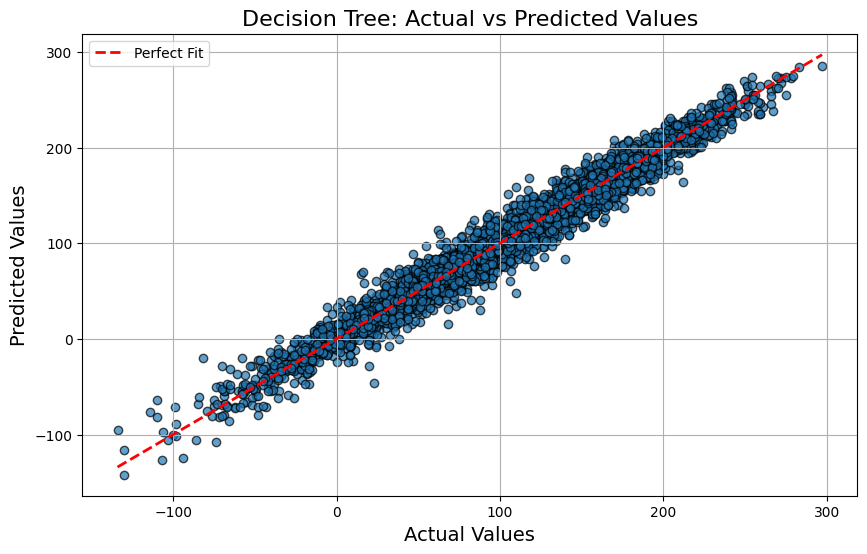

Feature Importances:
  Feature  Importance
3      TX    0.906730
4      TN    0.079379
1      QQ    0.005166
2      SS    0.005025
0      HU    0.003700
Best Parameters from Grid Search: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best Cross-Validated MSE: 100.28493157162629


In [23]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Define the target variable and features
TARGET_VARIABLE = 'TG'
FEATURES = ['HU', 'QQ', 'SS', 'TX', 'TN']

# Ensure we have valid rows from the previous merged data
if 'merged_data' in locals() and merged_data is not None:
    if all(feature in merged_data.columns for feature in FEATURES + [TARGET_VARIABLE]):
        valid_data = merged_data.dropna()

        # Separate features (X) and target variable (y)
        X = valid_data[FEATURES]
        y = valid_data[TARGET_VARIABLE]

        # Split data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Initialize a Decision Tree Regressor
        tree = DecisionTreeRegressor(random_state=42)

        # Train the model
        tree.fit(X_train, y_train)

        # Make predictions
        y_pred = tree.predict(X_test)

        # Evaluate the model
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Print results
        print("Mean Squared Error (MSE):", mse)
        print("R^2 Score:", r2)

        # Plot Actual vs Predicted Values
        plt.figure(figsize=(10, 6))
        plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect Fit")
        plt.title('Decision Tree: Actual vs Predicted Values', fontsize=16)
        plt.xlabel('Actual Values', fontsize=14)
        plt.ylabel('Predicted Values', fontsize=14)
        plt.legend()
        plt.grid(True)
        plt.show()

        # Feature Importance
        feature_importances = pd.DataFrame({
            'Feature': FEATURES,
            'Importance': tree.feature_importances_
        }).sort_values(by='Importance', ascending=False)
        print("Feature Importances:")
        print(feature_importances)

        # Hyperparameter Tuning using Grid Search
        param_grid = {
            'max_depth': [3, 5, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
        grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error')
        grid_search.fit(X, y)

        print("Best Parameters from Grid Search:", grid_search.best_params_)
        print("Best Cross-Validated MSE:", -grid_search.best_score_)

    else:
        print("Required columns are missing in the dataset.")
else:
    print("No valid data for decision tree analysis.")


In [1]:
# import matplotlib.pyplot as plt
# from sklearn.neural_network import MLPRegressor
# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import mean_squared_error, r2_score
# import pandas as pd

# # Define the target variable and features
# TARGET_VARIABLE = 'TG'
# FEATURES = ['HU', 'QQ', 'SS', 'TX', 'TN']

# # Ensure we have valid rows from the previous merged data
# if 'merged_data' in locals() and merged_data is not None:
#     if all(feature in merged_data.columns for feature in FEATURES + [TARGET_VARIABLE]):
#         valid_data = merged_data.dropna()

#         # Separate features (X) and target variable (y)
#         X = valid_data[FEATURES]
#         y = valid_data[TARGET_VARIABLE]

#         # Standardize the features (Neural networks often perform better with standardized data)
#         scaler = StandardScaler()
#         X_scaled = scaler.fit_transform(X)

#         # Split data into training and testing sets
        # X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

        # # Initialize the Neural Network model
        # nn_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)

        # # Train the model
        # nn_model.fit(X_train, y_train)

        # # Make predictions
        # y_pred = nn_model.predict(X_test)

        # # Evaluate the model
        # mse = mean_squared_error(y_test, y_pred)
        # r2 = r2_score(y_test, y_pred)

        # # Print results
        # print("Mean Squared Error (MSE):", mse)
        # print("R^2 Score:", r2)

        # # Plot Actual vs Predicted Values
        # plt.figure(figsize=(10, 6))
        # plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')
        # plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect Fit")
        # plt.title('Neural Network: Actual vs Predicted Values', fontsize=16)
        # plt.xlabel('Actual Values', fontsize=14)
        # plt.ylabel('Predicted Values', fontsize=14)
        # plt.legend()
        # plt.grid(True)
        # plt.show()

        # # Hyperparameter Tuning using GridSearchCV
        # param_grid = {
        #     'hidden_layer_sizes': [(100,), (50, 50), (100, 50)],
        #     'activation': ['relu', 'tanh'],
        #     'solver': ['adam', 'lbfgs'],
        #     'learning_rate': ['constant', 'adaptive']
#         }
#         grid_search = GridSearchCV(MLPRegressor(max_iter=1000, random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error')
#         grid_search.fit(X_scaled, y)

#         print("Best Parameters from Grid Search:", grid_search.best_params_)
#         print("Best Cross-Validated MSE:", -grid_search.best_score_)

#     else:
#         print("Required columns are missing in the dataset.")
# else:
#     print("No valid data for neural network analysis.")
